# Titanic Survival Prediction — Exploratory Data Analysis

Exploring how survival relates to sex, class, age, fare, and family size in the Kaggle Titanic dataset, ahead of feature engineering and modelling.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
df = pd.read_csv("../data/raw/titanic.csv")
df.shape

(891, 12)

## Overview

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [3]:
df.isna().mean().sort_values(ascending=False).round(3)

Cabin          0.771
Age            0.199
Embarked       0.002
PassengerId    0.000
Name           0.000
Pclass         0.000
Survived       0.000
Sex            0.000
Parch          0.000
SibSp          0.000
Fare           0.000
Ticket         0.000
dtype: float64

In [4]:
df["Survived"].value_counts(normalize=True).round(3)

Survived
0    0.616
1    0.384
Name: proportion, dtype: float64

About 38% of passengers in the training data survived — a mildly imbalanced target, which is why cross-validation uses stratified folds and evaluation looks beyond raw accuracy (precision/recall/F1/ROC-AUC).

## Survival by Sex

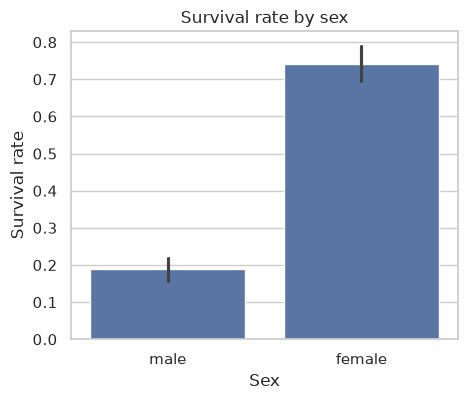

In [5]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(data=df, x="Sex", y="Survived", ax=ax)
ax.set_ylabel("Survival rate")
ax.set_title("Survival rate by sex")
plt.show()

## Survival by Passenger Class

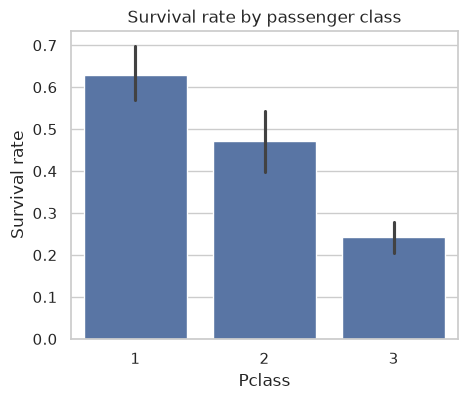

In [6]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(data=df, x="Pclass", y="Survived", ax=ax)
ax.set_ylabel("Survival rate")
ax.set_title("Survival rate by passenger class")
plt.show()

## Survival by Age Band

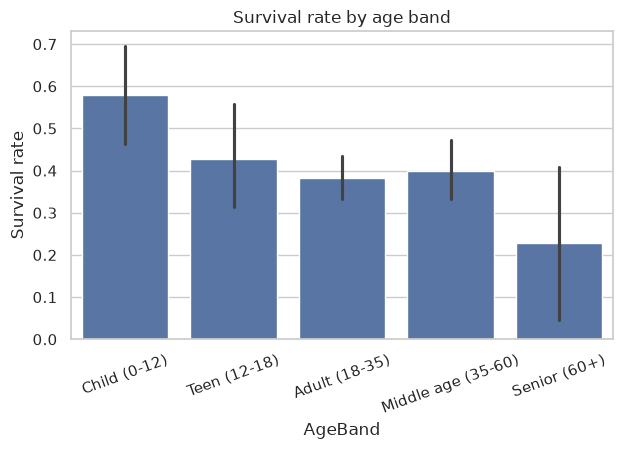

In [7]:
age_bins = [0, 12, 18, 35, 60, 100]
age_labels = ["Child (0-12)", "Teen (12-18)", "Adult (18-35)", "Middle age (35-60)", "Senior (60+)"]
df["AgeBand"] = pd.cut(df["Age"], bins=age_bins, labels=age_labels)
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=df, x="AgeBand", y="Survived", ax=ax)
ax.set_ylabel("Survival rate")
ax.set_title("Survival rate by age band")
plt.xticks(rotation=20)
plt.show()

## Fare Distribution by Survival

/tmp/ipykernel_15795/2019171221.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["Did not survive", "Survived"])


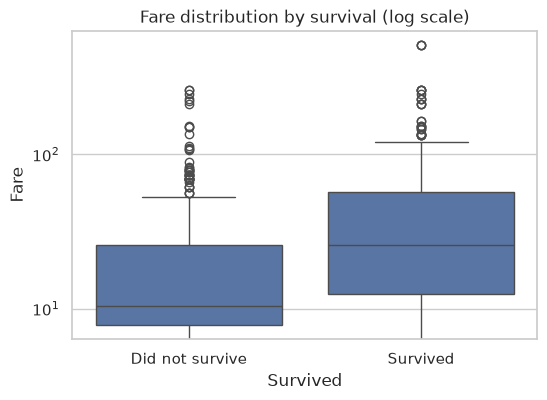

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=df, x="Survived", y="Fare", ax=ax)
ax.set_yscale("log")
ax.set_xticklabels(["Did not survive", "Survived"])
ax.set_title("Fare distribution by survival (log scale)")
plt.show()

## Survival by Family Size

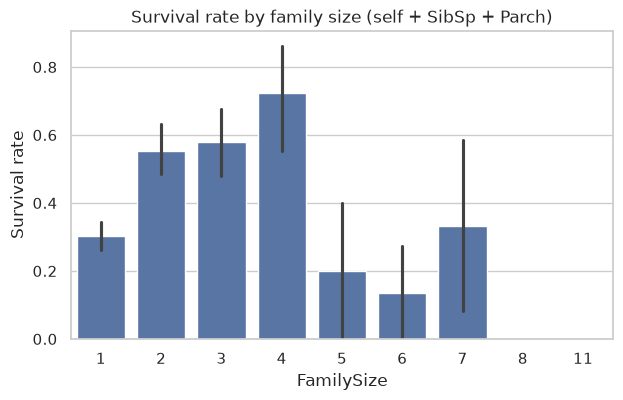

In [9]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=df, x="FamilySize", y="Survived", ax=ax)
ax.set_ylabel("Survival rate")
ax.set_title("Survival rate by family size (self + SibSp + Parch)")
plt.show()

## Survival by Embarkation Port

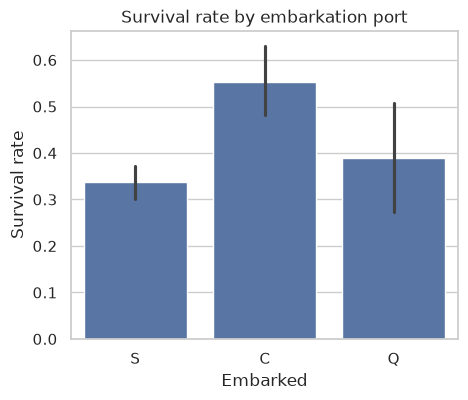

In [10]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(data=df, x="Embarked", y="Survived", ax=ax)
ax.set_ylabel("Survival rate")
ax.set_title("Survival rate by embarkation port")
plt.show()

## Takeaways

- **Sex** is the single strongest signal: women survived at a much higher rate than men.
- **Class** and **fare** both track survival, consistent with each other (fare is a proxy for class).
- **Children** survived at a higher rate than adults; very large families (5+) survived at a lower rate than small families, likely reflecting difficulty evacuating together.
- These patterns motivate the engineered features used in modelling: `Title` (captures age/sex/social status jointly), `FamilySize` / `IsAlone`, and `HasCabin` as a proxy for the missing Cabin field.